# I. Introduction

## Mục tiêu
Mô hình này dự đoán xem một loài động vật có "Dangerous" (nguy hiểm) hay không dựa trên tên động vật và tối đa 5 triệu chứng (symptoms1..symptoms5). Sử dụng SVM cho bài toán phân loại nhị phân.

## Dữ liệu
- Cột chính: AnimalName, symptoms1, symptoms2, symptoms3, symptoms4, symptoms5, Dangerous
- Dangerous: nhãn (Yes/No) — sẽ chuyển thành 0/1
- Giả định: mỗi dòng là một mẫu độc lập; số mẫu không cố định (kiểm tra bằng `data.shape`)

## Quy trình (tóm tắt)
1. Đọc dữ liệu (data.csv)
2. Tiền xử lý:
   - Mã hóa nhãn Dangerous (Yes -> 1, No -> 0)
   - One-Hot Encoding cho các biến phân loại (AnimalName, symptoms*)
3. Tách train/test (80/20) với stratify để giữ cân bằng lớp
4. Huấn luyện SVM (kernel='linear')
5. Đánh giá: accuracy, confusion matrix, classification report
6. Cải thiện: cross-validation, grid search, feature importance, learning curve, ROC


## 1. Import các thư viện cần thiết để chạy mô hình

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

## 2. Input data

In [6]:
data=pd.read_csv('data.csv')
data.head()

,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
0,Dog,Fever,Diarrhea,Vomiting,Weight loss,Dehydration,Yes
1,Dog,Fever,Diarrhea,Coughing,Tiredness,Pains,Yes
2,Dog,Fever,Diarrhea,Coughing,Vomiting,Anorexia,Yes
3,Dog,Fever,Difficulty breathing,Coughing,Lethargy,Sneezing,Yes
4,Dog,Fever,Diarrhea,Coughing,Lethargy,Blue Eye,Yes


In [9]:
# Hiển thị 5 dòng đầu tiên và thông tin cột để kiểm tra
print("--- 5 dòng dữ liệu đầu tiên ---")
print(data.head())
print("\n--- Thông tin cột ---")
print(data.info())

--- 5 dòng dữ liệu đầu tiên ---
  AnimalName symptoms1             symptoms2 symptoms3    symptoms4  \
0        Dog     Fever              Diarrhea  Vomiting  Weight loss   
1        Dog     Fever              Diarrhea  Coughing    Tiredness   
2        Dog     Fever              Diarrhea  Coughing     Vomiting   
3        Dog     Fever  Difficulty breathing  Coughing     Lethargy   
4        Dog     Fever              Diarrhea  Coughing     Lethargy   

     symptoms5 Dangerous  
0  Dehydration       Yes  
1        Pains       Yes  
2     Anorexia       Yes  
3     Sneezing       Yes  
4     Blue Eye       Yes  

--- Thông tin cột ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 871 entries, 0 to 870
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   AnimalName  871 non-null    object
 1   symptoms1   871 non-null    object
 2   symptoms2   871 non-null    object
 3   symptoms3   871 non-null    object
 4   symptom

## 3. Tiền xử lý Dữ liệu (Feature Engineering)

### 3.1 Chuyển 'Yes' thành 1 và 'No' thành 0

In [10]:
data['Dangerous_Encoded'] = data['Dangerous'].apply(lambda x: 1 if x == 'Yes' else 0)
Y = data['Dangerous_Encoded']

### 3.2. Mã hóa One-Hot (One-Hot Encoding) cho Biến Tính năng Phân loại

In [12]:
# SVM yêu cầu đầu vào là dữ liệu số
feature_cols = ['AnimalName', 'symptoms1', 'symptoms2', 'symptoms3', 'symptoms4', 'symptoms5']
df_encoded = pd.get_dummies(data, columns=feature_cols, prefix=feature_cols)

### 3.3. Xác định Tập Tính năng (X)

In [14]:
# Loại bỏ các cột không cần thiết (cột gốc và cột mục tiêu)
columns_to_drop = ['Dangerous', 'Dangerous_Encoded'] + feature_cols
X = df_encoded.drop(columns=columns_to_drop, axis=1, errors='ignore')

# Kiểm tra shape của X để đảm bảo
print("Shape of X:", X.shape)
print(f"Kích thước tập tính năng (X) sau One-Hot Encoding: {X.shape}")
print(f"Số lượng mẫu (Y): {Y.shape[0]}")

Shape of X: (871, 1157)
Kích thước tập tính năng (X) sau One-Hot Encoding: (871, 1157)
Số lượng mẫu (Y): 871


### 3.4. Tách dữ liệu thành Tập Huấn luyện và Tập Kiểm tra

In [16]:
# Tỷ lệ 80% Huấn luyện, 20% Kiểm tra
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, 
    test_size=0.2, 
    random_state=42,  # Đảm bảo kết quả có thể tái lập
    stratify=Y  # Giữ tỷ lệ lớp (0 và 1) tương đương trong tập train/test
)

# In kích thước của các tập dữ liệu
print(f"Kích thước tập huấn luyện (X_train): {X_train.shape}")
print(f"Kích thước tập kiểm tra (X_test): {X_test.shape}")

Kích thước tập huấn luyện (X_train): (696, 1157)
Kích thước tập kiểm tra (X_test): (175, 1157)


## 4. Huấn luyện Mô hình SVM (Support Vector Classification)

In [25]:

# Khởi tạo mô hình SVC với kernel tuyến tính
svm_model = SVC(kernel='linear', random_state=42)

print("Bắt đầu huấn luyện...")
# Huấn luyện mô hình trên tập huấn luyện
svm_model.fit(X_train, Y_train)
print("Huấn luyện hoàn tất.")

# Đánh giá mô hình trên tập kiểm tra
Y_pred = svm_model.predict(X_test)
accuracy = svm_model.score(X_test, Y_test)
print(f"\nĐộ chính xác trên tập kiểm tra: {accuracy:.2%}")

Bắt đầu huấn luyện...
Huấn luyện hoàn tất.

Độ chính xác trên tập kiểm tra: 100.00%


## 5. Đánh giá mô hình

=== Kết quả đánh giá mô hình ===

Tổng số mẫu kiểm tra: 175
Số lượng dự đoán đúng: 175.0

✅ Độ chính xác (Accuracy) của mô hình SVM: 1.0000

Confusion Matrix:
[[  4   0]
 [  0 171]]

Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00       171

    accuracy                           1.00       175
   macro avg       1.00      1.00      1.00       175
weighted avg       1.00      1.00      1.00       175



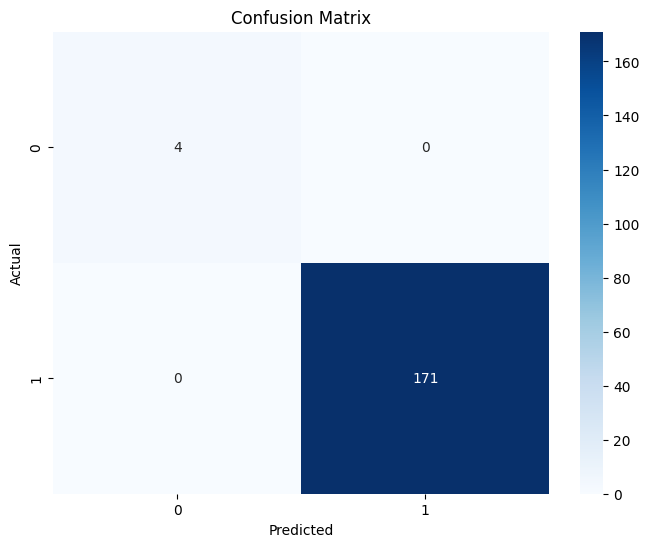

In [26]:
# Dự đoán trên tập kiểm tra
Y_pred = svm_model.predict(X_test)

# Tính toán các metrics
accuracy = accuracy_score(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)
class_report = classification_report(Y_test, Y_pred)

# In kết quả đánh giá
print("=== Kết quả đánh giá mô hình ===")
print(f"\nTổng số mẫu kiểm tra: {len(Y_test)}")
print(f"Số lượng dự đoán đúng: {accuracy_score(Y_test, Y_pred, normalize=False)}")
print(f"\n✅ Độ chính xác (Accuracy) của mô hình SVM: {accuracy:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nBáo cáo phân loại chi tiết:")
print(class_report)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 6. Cái thiện mô hình

### 6.1. Cross-validation

In [29]:
print("\n=== Cross-validation ===")
cv_scores = cross_val_score(svm_model, X, Y, cv=5)
print(f"Độ chính xác trung bình: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


=== Cross-validation ===
Độ chính xác trung bình: 1.0000 (+/- 0.0000)


### 6.2.  Grid Search để tối ưu tham số

In [30]:
print("\n=== Tối ưu hóa tham số ===")
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, Y_train)

print(f"Tham số tốt nhất: {grid_search.best_params_}")
print(f"Độ chính xác tốt nhất: {grid_search.best_score_:.4f}")


=== Tối ưu hóa tham số ===
Tham số tốt nhất: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Độ chính xác tốt nhất: 0.9914


### 6.3. Feature Importance Analysis


=== Phân tích đặc trưng quan trọng ===


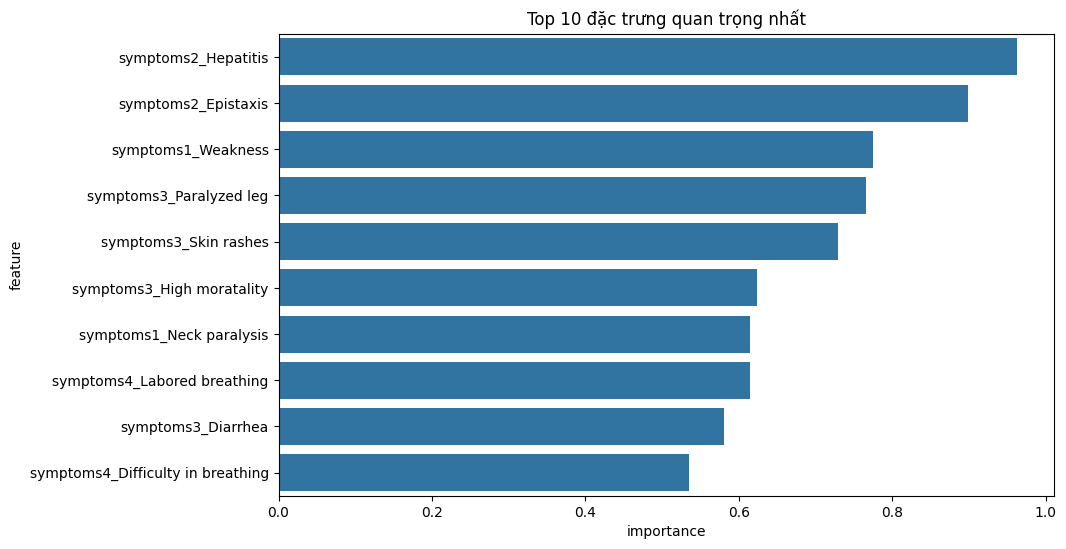

In [31]:
print("\n=== Phân tích đặc trưng quan trọng ===")
def plot_feature_importance(model, feature_names):
    importance = np.abs(model.coef_[0])
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    })
    feature_importance = feature_importance.sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
    plt.title('Top 10 đặc trưng quan trọng nhất')
    plt.show()

plot_feature_importance(svm_model, X.columns)

### 6.4. Learning Curve Analysis


=== Phân tích đường cong học tập ===


c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
8 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
8 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ACER\AppData\Loca

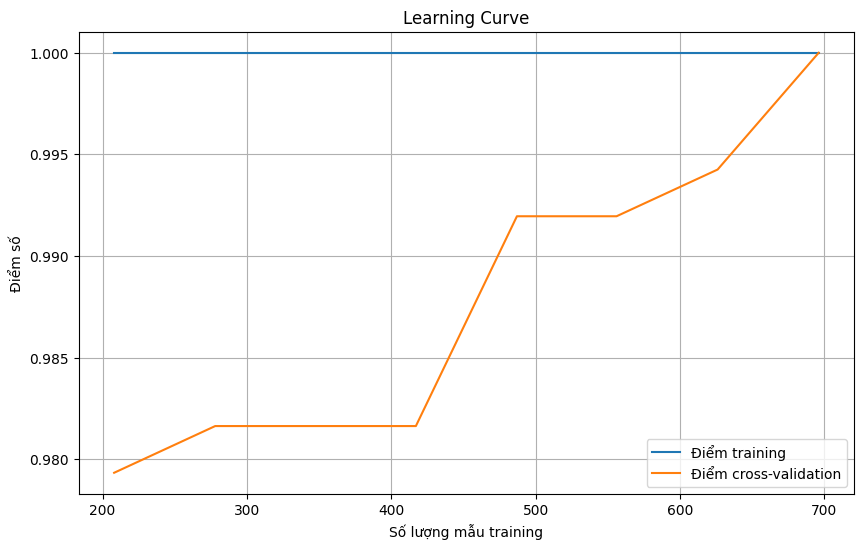

In [32]:
print("\n=== Phân tích đường cong học tập ===")
def plot_learning_curve(estimator, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10))
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, label='Điểm training')
    plt.plot(train_sizes, test_mean, label='Điểm cross-validation')
    plt.xlabel('Số lượng mẫu training')
    plt.ylabel('Điểm số')
    plt.title('Learning Curve')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

plot_learning_curve(svm_model, X, Y)

### 6.5. ROC Curve Analysis


=== Phân tích ROC Curve ===


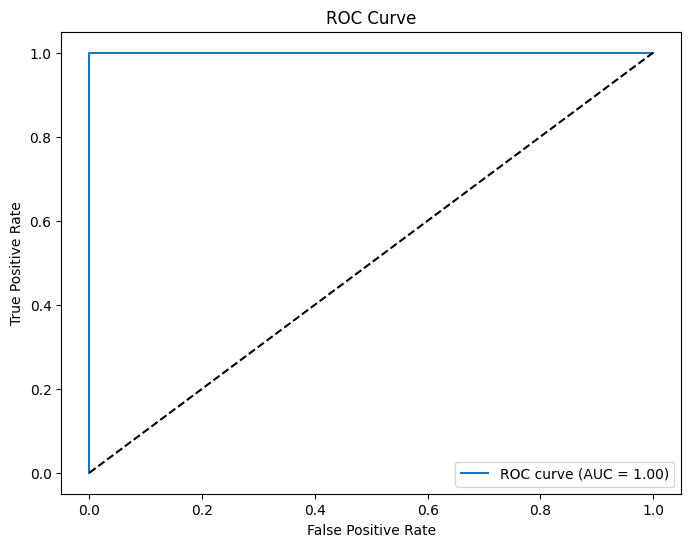

In [33]:
print("\n=== Phân tích ROC Curve ===")
# Cần khởi tạo lại mô hình với probability=True
svm_model_prob = SVC(kernel='linear', probability=True)
svm_model_prob.fit(X_train, Y_train)
y_pred_proba = svm_model_prob.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()